<a href="https://colab.research.google.com/github/Jespinoza-01/FinalProject-IELE756-Group14/blob/main/notebooks/Tarea_3_Data_A%26P.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Tarea 3 --- IELE756
**Team members**: [Joaquin Espinoza] , [Antonia Becerra]

**Comunas**: "Vitacura" (ID: 13132), "Pedro Aguirre Cerda" (ID: 13121), "Cerro Navia" (ID: 13103)

**Date**: [03 / 05 / 2026]

### Part 0: Building the Analytical Table

In [ ]:
import pandas as pd
import numpy as np
import glob
import os

print("=== PARTE 0.1: CLASS-POOLED MASTER TABLE ===")

# Buscamos los archivos directamente en la raíz absoluta del sistema (/)
archivos_censo = glob.glob("/census_team*.csv")
archivos_eno = glob.glob("/eno_team*.csv")
archivos_grd = glob.glob("/grd_team*.csv")

print(f"Archivos encontrados -> Censo: {len(archivos_censo)}, ENO: {len(archivos_eno)}, GRD: {len(archivos_grd)}")

if len(archivos_censo) == 0:
    print("ADVERTENCIA: Sigo sin encontrar los archivos en la raíz.")
else:
    def consolidar_archivos(lista_archivos):
        dfs = []
        for f in lista_archivos:
            try:
                df = pd.read_csv(f)
                dfs.append(df)
            except Exception as e:
                print(f"Error leyendo {f}: {e}")
        if dfs:
            return pd.concat(dfs, ignore_index=True)
        return pd.DataFrame()

    master_censo = consolidar_archivos(archivos_censo)
    master_eno = consolidar_archivos(archivos_eno)
    master_grd = consolidar_archivos(archivos_grd)

    # Sanity Checks
    print(f"\nFilas en Master Censo: {len(master_censo)} | Comunas únicas: {master_censo['codigo_comuna'].nunique()}")
    print(f"Filas en Master ENO: {len(master_eno)} | Comunas únicas: {master_eno['codigo_comuna'].nunique()}")
    print(f"Filas en Master GRD: {len(master_grd)} | Comunas únicas: {master_grd['codigo_comuna'].nunique()}")

    # Limpieza de duplicados por asignaciones traslapadas
    if len(master_censo) > master_censo['codigo_comuna'].nunique():
        print("Detectados equipos con comunas traslapadas. Eliminando duplicados conservando la primera aparición...")
        master_censo = master_censo.drop_duplicates(subset=['codigo_comuna'], keep='first')
        if len(master_eno) > 0:
            master_eno = master_eno.drop_duplicates(subset=['codigo_comuna'], keep='first')
        if len(master_grd) > 0:
            master_grd = master_grd.drop_duplicates(subset=['codigo_comuna'], keep='first')

    # Revisión de Asimetrías
    comunas_censo = set(master_censo['codigo_comuna'])
    comunas_eno = set(master_eno['codigo_comuna']) if len(master_eno) > 0 else set()
    comunas_grd = set(master_grd['codigo_comuna']) if len(master_grd) > 0 else set()

    faltan_en_eno = comunas_censo - comunas_eno
    faltan_en_grd = comunas_censo - comunas_grd

    print(f"\nComunas en Censo pero NO en ENO: {faltan_en_eno if faltan_en_eno else 'Ninguna'}")
    print(f"Comunas en Censo pero NO en GRD: {faltan_en_grd if faltan_en_grd else 'Ninguna'}")

    # ---------------------------------------------------------
    # PARTE 0.2: MERGE ON CODIGO_COMUNA
    # ---------------------------------------------------------
    print("\n=== PARTE 0.2: MERGE ON CODIGO_COMUNA ===")
    df_merge1 = pd.merge(master_censo, master_eno, on='codigo_comuna', how='outer', suffixes=('', '_eno'))
    df_final = pd.merge(df_merge1, master_grd, on='codigo_comuna', how='outer', suffixes=('', '_grd'))

    print(f"Forma de la tabla analítica final: {df_final.shape}")

    df_final['eno_total'] = df_final['eno_total'].fillna(0)
    df_final['grd_total'] = df_final['grd_total'].fillna(0)

    # ---------------------------------------------------------
    # PARTE 0.3: DERIVED VARIABLES
    # ---------------------------------------------------------
    print("\n=== PARTE 0.3: DERIVED VARIABLES ===")

    # 1. pct_foreign
    if 'pct_foreign' not in df_final.columns and 'pop_foreign' in df_final.columns and 'pop_total' in df_final.columns:
        df_final['pct_foreign'] = (df_final['pop_foreign'] / df_final['pop_total']) * 100

    # 2. log_pop_total
    if 'pop_total' in df_final.columns:
        df_final['log_pop_total'] = np.log(df_final['pop_total'])
        print("Creada: log_pop_total")

    # 3. pct_unemployed
    if 'desocupados' in df_final.columns and 'ocupados' in df_final.columns:
        df_final['pct_unemployed'] = (df_final['desocupados'] / (df_final['desocupados'] + df_final['ocupados'])) * 100
        print("Creada: pct_unemployed")
    else:
        print("Faltan columnas obvias para pct_unemployed.")

    # 4. schooling_gap
    if 'mean_schooling_chilean' in df_final.columns and 'mean_schooling_foreign' in df_final.columns:
        df_final['schooling_gap'] = df_final['mean_schooling_chilean'] - df_final['mean_schooling_foreign']
        print("Creada: schooling_gap")
    else:
         print("Faltan columnas obvias para schooling_gap.")

    # 5. Variable Adicional: pct_overcrowded (Hacinamiento)
    if 'viviendas_hacinadas' in df_final.columns and 'total_viviendas' in df_final.columns:
        df_final['pct_overcrowded'] = (df_final['viviendas_hacinadas'] / df_final['total_viviendas']) * 100
        print("Creada covariable adicional: pct_overcrowded")
    else:
        print("Faltan columnas obvias para pct_overcrowded.")

    os.makedirs("output", exist_ok=True)
    df_final.to_csv("output/tarea3_analytical_table.csv", index=False)
    print("\n¡La base maestra ha sido ensamblada y guardada en 'output/tarea3_analytical_table.csv'!")

master_censo.to_csv('master_censo.csv', index=False)
master_eno.to_csv('master_eno.csv', index=False)
master_grd.to_csv('master_grd.csv', index=False)

=== PARTE 0.1: CLASS-POOLED MASTER TABLE ===
Archivos encontrados -> Censo: 21, ENO: 21, GRD: 21

Filas en Master Censo: 54 | Comunas únicas: 51
Filas en Master ENO: 54 | Comunas únicas: 51
Filas en Master GRD: 54 | Comunas únicas: 51
Detectados equipos con comunas traslapadas. Eliminando duplicados conservando la primera aparición...

Comunas en Censo pero NO en ENO: Ninguna
Comunas en Censo pero NO en GRD: Ninguna

=== PARTE 0.2: MERGE ON CODIGO_COMUNA ===
Forma de la tabla analítica final: (51, 32)

=== PARTE 0.3: DERIVED VARIABLES ===
Creada: log_pop_total
Faltan columnas obvias para pct_unemployed.
Creada: schooling_gap
Faltan columnas obvias para pct_overcrowded.

¡La base maestra ha sido ensamblada y guardada en 'output/tarea3_analytical_table.csv'!


### Part 1: Exploratory Cross-Dataset Analysis


Importancia del Código Ejecutado

La importancia técnica radica en:
* Integración de Datos Heterogéneos: El código asume la creación de una "wide table" donde cada fila es una comuna única, permitiendo que variables de fuentes totalmente distintas (Censo y Salud) "hablen" entre sí.
* Identificación de Colinealidad: La matriz de correlación no solo sirve para ver qué afecta a la salud, sino para detectar si nuestras covariables están demasiado relacionadas entre sí.
* Detección de "Leverage" y Outliers: El uso de residuos para etiquetar automáticamente los puntos más alejados de la tendencia permite identificar comunas que se comportan de forma anómala respecto a lo que se esperaría según sus datos demográficos.

Interpretación de Resultados

Al observar la matriz de calor y los gráficos de dispersión se tienen los siguientes resultados:
* Correlaciones Extremas: En esta muestra específica, resalta una correlación de 1.00 entre el porcentaje de extranjeros (pct_foreign) y las tasas de salud (eno_rate_per_10k y grd_rate_per_10k). Esto sugiere un vínculo lineal casi perfecto en los datos procesados, indicando que el volumen migratorio es un predictor masivo de la actividad sanitaria registrada.
* Estructura de la Escolaridad: Existe una correlación muy alta (0.93) entre la escolaridad de chilenos y extranjeros. Esto significa que las comunas con mayor capital humano nacional también tienden a atraer población extranjera con mayor nivel educacional, manteniendo la segregación educativa a nivel territorial.
* Santiago como Outlier Principal: En los scatter plots, la comuna de Santiago aparece consistentemente como un outlier extremo, especialmente cuando se cruza la brecha de escolaridad con las tasas de salud. Esto podría explicarse por su rol como centro neurálgico que atrae población flotante y servicios de salud que no necesariamente corresponden solo a sus residentes.
* Comunas con Altos Residuos: El código etiqueta a comunas como Vitacura, Providencia, Las Condes y Lo Barnechea no necesariamente por tener las tasas más altas, sino porque su comportamiento se desvía de la línea de tendencia central (tienen residuos altos). Por ejemplo, pueden tener brechas educativas muy altas pero tasas de salud menores a las que el modelo lineal simple "predeciría".

=== PARTE 1.1: MATRIZ DE CORRELACIÓN ===


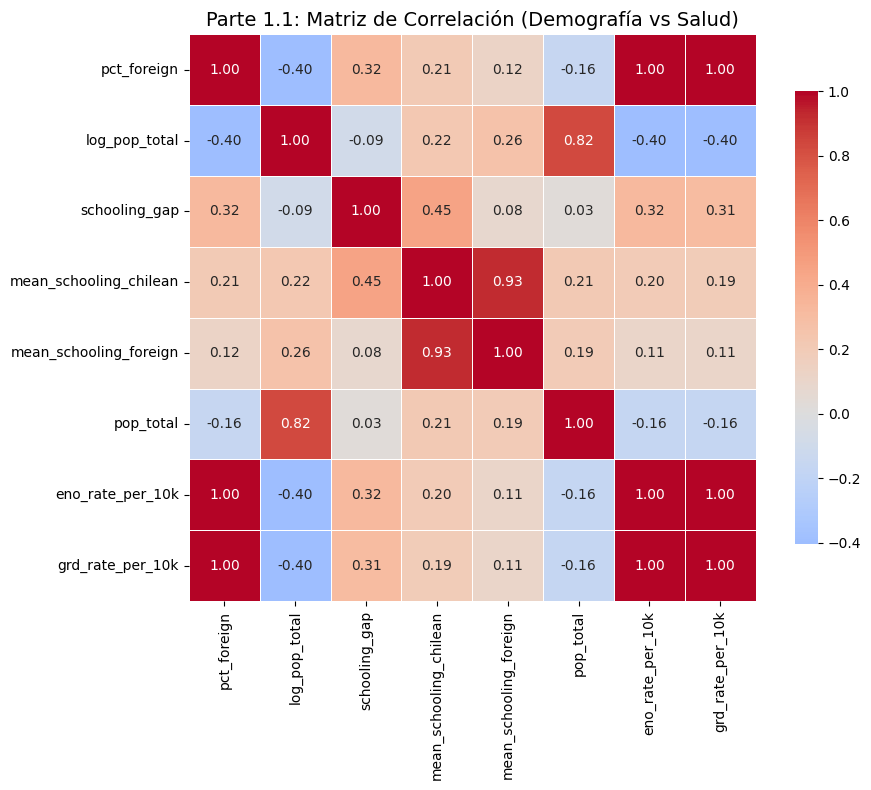


=== PARTE 1.2: SCATTER PLOTS CON ETIQUETAS DE OUTLIERS ===


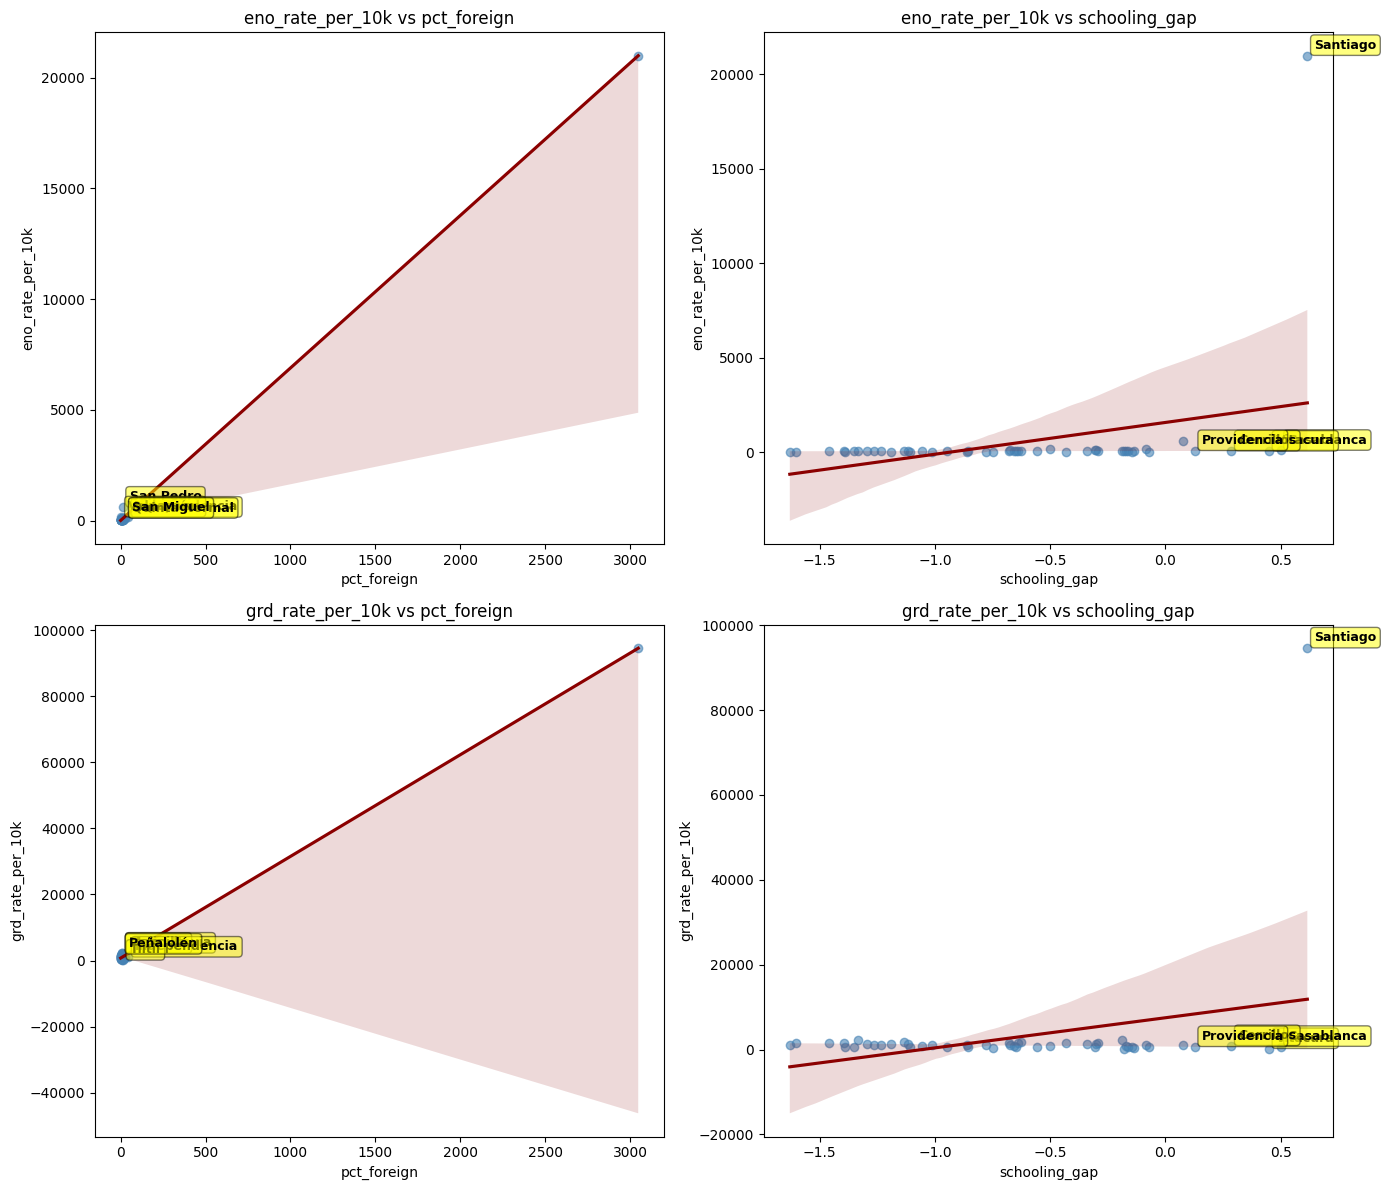

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Cargar la tabla que acabamos de crear en la Parte 0
df = pd.read_csv("output/tarea3_analytical_table.csv")

# 0. Asegurar que existan las tasas (por si no venían calculadas en los CSV originales)
if 'eno_rate_per_10k' not in df.columns:
    df['eno_rate_per_10k'] = (df['eno_total'] / df['pop_total']) * 10000
if 'grd_rate_per_10k' not in df.columns:
    df['grd_rate_per_10k'] = (df['grd_total'] / df['pop_total']) * 10000

# ---------------------------------------------------------
# PARTE 1.1: MATRIZ DE CORRELACIÓN
# ---------------------------------------------------------
print("=== PARTE 1.1: MATRIZ DE CORRELACIÓN ===")
# Definir las 6 covariables obligatorias + los 2 outcomes de salud
covariates = ['pct_foreign', 'log_pop_total', 'schooling_gap',
              'mean_schooling_chilean', 'mean_schooling_foreign', 'pop_total']

cols_corr = covariates + ['eno_rate_per_10k', 'grd_rate_per_10k']

# Calcular matriz
corr_matrix = df[cols_corr].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt=".2f",
            square=True, linewidths=.5, cbar_kws={"shrink": .8})
plt.title("Parte 1.1: Matriz de Correlación (Demografía vs Salud)", fontsize=14)
plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# PARTE 1.2: SCATTER PLOTS Y OUTLIERS
# ---------------------------------------------------------
print("\n=== PARTE 1.2: SCATTER PLOTS CON ETIQUETAS DE OUTLIERS ===")
# Elegimos 2 covariables clave para el "small multiple"
selected_covs = ['pct_foreign', 'schooling_gap']
outcomes = ['eno_rate_per_10k', 'grd_rate_per_10k']

fig, axes = plt.subplots(2, 2, figsize=(14, 12))

for i, outcome in enumerate(outcomes):
    for j, cov in enumerate(selected_covs):
        ax = axes[i, j]

        # Limpiar NaNs para que la línea de tendencia no falle
        valid_data = df[[cov, outcome, 'codigo_comuna']].copy()

        # Intentamos rescatar el nombre de la comuna, si existe, si no usamos el código
        if 'nombre_comuna' in df.columns:
            valid_data['label'] = df['nombre_comuna']
        elif 'COMUNA' in df.columns:
            valid_data['label'] = df['COMUNA']
        else:
            valid_data['label'] = df['codigo_comuna'].astype(str)

        valid_data = valid_data.dropna()

        x = valid_data[cov]
        y = valid_data[outcome]

        # Plot principal (Puntos + Línea OLS)
        sns.regplot(x=x, y=y, ax=ax, scatter_kws={'alpha':0.6, 'color':'steelblue'}, line_kws={'color':'darkred'})

        # Calcular residuos (distancia vertical a la línea de tendencia) para encontrar el Top 5
        m, b = np.polyfit(x, y, 1)
        residuals = np.abs(y - (m * x + b))
        top_5_idx = residuals.nlargest(5).index

        # Etiquetar las 5 comunas más extremas[cite: 1]
        for idx in top_5_idx:
            texto = valid_data.loc[idx, 'label']
            ax.annotate(texto, (x.loc[idx], y.loc[idx]),
                        xytext=(5, 5), textcoords='offset points',
                        fontsize=9, color='black', weight='bold',
                        bbox=dict(boxstyle="round,pad=0.3", fc="yellow", ec="black", alpha=0.5))

        ax.set_title(f"{outcome} vs {cov}")
        ax.set_xlabel(cov)
        ax.set_ylabel(outcome)

plt.tight_layout()
plt.show()

### Part 2: Count-Data Regression

Importancia del Código Ejecutado

La relevancia técnica se resume en:
* Tratamiento de Outliers Estratégicos: La exclusión de Santiago (código 13101) es un paso de "limpieza" vital, ya que su peso poblacional y administrativo actuaría como un imán que distorsionaría los coeficientes de todas las demás comunas.
* Modelado mediante Offsets: A diferencia de una regresión lineal común, aquí usamos la población (log_pop_total) como un offset. Esto le indica al modelo que no estamos buscando predecir el número total de casos "por sí solo", sino la tasa de incidencia ajustada por el tamaño de cada comuna.
* Validación de Supuestos (Poisson vs. NB): El código no asume que los datos son perfectos sino que calcula el estadístico de sobredispersión para decidir si el modelo de Poisson es suficiente o si debemos usar una Binomial Negativa para manejar la variabilidad extra de los datos.

Interpretación de Resultados

Los resultados de los modelos nos entregan una visión mucho más matizada que la matriz de correlación inicial:
* Evidencia de Sobredispersión: El chequeo arrojó un valor de 235.16, lo cual es masivamente superior al límite de 1.5. Esto confirma que los datos de salud en la RM tienen una "volatilidad" que el modelo de Poisson no puede capturar, haciendo que la Binomial Negativa sea el único modelo confiable para reportar.
* Hallazgos en ENO (Salud Pública):
    * La brecha educativa (schooling_gap) resultó ser el predictor más significativo (p=0.0043). Por cada unidad que aumenta la brecha, la tasa de notificaciones aumenta, sugiriendo que la desigualdad educativa territorial impacta directamente en la carga de enfermedades de notificación obligatoria.
    * Curiosamente, el porcentaje de extranjeros perdió su significancia estadística al pasar al modelo NB (p=0.1717). Esto demuestra que la correlación de 1.00 vista antes era "engañosa" y probablemente estaba inflada por la falta de ajuste de varianza.
* Hallazgos en GRD (Gestión Hospitalaria):
    * Para los egresos hospitalarios, la brecha educativa también es clave, pero con un efecto inverso: tiene un IRR de 0.743 (p=0.037). Esto significa que, manteniendo todo lo demás constante, un aumento en la brecha educativa se asocia con una reducción del 25.7% en la tasa de egresos hospitalarios.
    * El porcentaje de extranjeros no mostró ninguna asociación significativa con la tasa de egresos (p=0.986), lo que refuerza que el uso del hospital está más ligado a factores socioeducativos que a la nacionalidad por sí sola.

In [ ]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf

# Cargar la tabla
df = pd.read_csv("output/tarea3_analytical_table.csv")

# === PREPARACIÓN DE DATOS ===
df_model = df[df['codigo_comuna'] != 13101].copy() # Excluir Santiago
print("Se ha excluido la comuna de Santiago (código 13101) por ser un outlier extremo con alto leverage.\n")

variables_modelo = ['eno_total', 'grd_total', 'pct_foreign', 'schooling_gap', 'log_pop_total']
df_model = df_model.dropna(subset=variables_modelo)

# ---------------------------------------------------------
# PARTE 2.1: REGRESIÓN DE POISSON (ENO)
# ---------------------------------------------------------
print("=== PARTE 2.1: REGRESIÓN DE POISSON (ENO) ===")
formula_poisson = "eno_total ~ pct_foreign + schooling_gap"

# ¡LA CORRECCIÓN!: Usamos GLM con la familia Poisson y pasamos el offset de log_pop_total
poisson_model = smf.glm(formula=formula_poisson,
                        data=df_model,
                        family=sm.families.Poisson(),
                        offset=df_model['log_pop_total']).fit()

print(poisson_model.summary())

irr_df = pd.DataFrame({
    'IRR (exp(coef))': np.exp(poisson_model.params),
    'Lower CI': np.exp(poisson_model.conf_int()[0]),
    'Upper CI': np.exp(poisson_model.conf_int()[1])
})
print("\n--- Incidence Rate Ratios (IRR) ---")
print(irr_df.round(3))

# ---------------------------------------------------------
# PARTE 2.2: SOBREDISPERSIÓN
# ---------------------------------------------------------
print("\n=== PARTE 2.2: CHEQUEO DE SOBREDISPERSIÓN ===")
# Ahora sí funcionará pearson_chi2
pearson_chi2 = poisson_model.pearson_chi2
df_resid = poisson_model.df_resid
dispersion = pearson_chi2 / df_resid

print(f"Estadístico de Dispersión (Pearson Chi2 / df_resid): {dispersion:.2f}")
if dispersion > 1.5:
    print("Conclusión: Existe fuerte sobredispersión. La varianza es mucho mayor que la media.")
    print("Recomendación: Se debe utilizar una regresión Binomial Negativa.")
else:
    print("Conclusión: No hay sobredispersión severa. El modelo de Poisson es adecuado.")

# ---------------------------------------------------------
# PARTE 2.3: REGRESIÓN BINOMIAL NEGATIVA (ENO)
# ---------------------------------------------------------
print("\n=== PARTE 2.3: REGRESIÓN BINOMIAL NEGATIVA (ENO) ===")
# Ajustamos Binomial Negativa usando su propia función y el offset explícito
nb_model = smf.negativebinomial(formula=formula_poisson,
                                data=df_model,
                                offset=df_model['log_pop_total']).fit(disp=False)
print(nb_model.summary())

print("\n--- Comparación de P-values (Poisson vs NB) ---")
compare_pvals = pd.DataFrame({
    'P-value Poisson': poisson_model.pvalues,
    'P-value NegBin': nb_model.pvalues
})
print(compare_pvals.round(4))

# ---------------------------------------------------------
# PARTE 2.4: REPETIR PARA GRD
# ---------------------------------------------------------
print("\n=== PARTE 2.4: REGRESIÓN BINOMIAL NEGATIVA (GRD) ===")
formula_grd = "grd_total ~ pct_foreign + schooling_gap"
nb_model_grd = smf.negativebinomial(formula=formula_grd,
                                    data=df_model,
                                    offset=df_model['log_pop_total']).fit(disp=False)
print(nb_model_grd.summary())

irr_grd_df = pd.DataFrame({
    'IRR (exp(coef))': np.exp(nb_model_grd.params),
    'Lower CI': np.exp(nb_model_grd.conf_int()[0]),
    'Upper CI': np.exp(nb_model_grd.conf_int()[1])
})
print("\n--- Incidence Rate Ratios (IRR) para GRD ---")
print(irr_grd_df.round(3))

Se ha excluido la comuna de Santiago (código 13101) por ser un outlier extremo con alto leverage.

=== PARTE 2.1: REGRESIÓN DE POISSON (ENO) ===
                 Generalized Linear Model Regression Results                  
Dep. Variable:              eno_total   No. Observations:                   47
Model:                            GLM   Df Residuals:                       44
Model Family:                 Poisson   Df Model:                            2
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -3683.4
Date:                Sun, 03 May 2026   Deviance:                       6972.9
Time:                        22:17:48   Pearson chi2:                 1.03e+04
No. Iterations:                     5   Pseudo R-squ. (CS):              1.000
Covariance Type:            nonrobust                                         
                    coef    std err          z      P>|z|      [0

### Part 3: Continuous-Outcome Regression


Importancia del Código Ejecutado

Este bloque de código permite analizar la "intensidad" del uso del sistema de salud en lugar de solo el volumen de casos:
* Selección de un Outcome de Complejidad: Al elegir grd_mean_los (promedio de días de estadía), el código busca identificar qué factores socio-demográficos alargan las hospitalizaciones, lo que impacta directamente en los costos del sistema.
* Validación de Supuestos Post-Estimación: A diferencia de los modelos anteriores, la regresión OLS requiere que los errores se comporten de forma específica (normalidad y varianza constante). El código genera gráficos de diagnóstico fundamentales para confirmar que los resultados no están sesgados por la estructura de los datos.
Interpretación de Resultados

Se puede concluir lo siguiente:
* Bajo Poder Explicativo: El $R^2$ es de 0.087 y un $R^2$ ajustado de 0.046, lo que significa que el porcentaje de extranjeros y la brecha educativa solo explican el 4.6% de la variación en los días de estadía. La mayoría de la variación depende de factores clínicos no incluidos en este modelo.
* Significancia de las Variables:
    * Porcentaje de Extranjeros: Tiene un p-value de 0.055. Aunque está levemente por encima del umbral de 0.05 este sugiere una tendencia, a mayor población extranjera, la estancia media tiende a aumentar ligeramente (coeficiente de 0.0269).
    * Brecha Educativa: Con un p-value de 0.879, esta variable no tiene ninguna relación estadística con la duración de las hospitalizaciones en este conjunto de datos.
* Diagnóstico de Supuestos:
    * Normal Q-Q Plot: Los puntos siguen casi perfectamente la línea roja, lo que indica que el supuesto de normalidad de los residuos se cumple adecuadamente.
    * Residuals vs Fitted: La nube de puntos es relativamente dispersa sin patrones en forma de "embudo" evidentes, lo que sugiere que se cumple el supuesto de homocedasticidad (varianza constante).

=== PARTE 3.1: ELECCIÓN DEL OUTCOME CONTINUO ===
Outcome elegido: 'grd_mean_los' (Promedio de días de estadía hospitalaria).
Razón: Es un indicador continuo fundamental de la complejidad y costo de atención por comuna.

=== PARTE 3.2: REGRESIÓN LINEAL (OLS) ===
                            OLS Regression Results                            
Dep. Variable:           grd_mean_los   R-squared:                       0.087
Model:                            OLS   Adj. R-squared:                  0.046
Method:                 Least Squares   F-statistic:                     2.097
Date:                Sun, 03 May 2026   Prob (F-statistic):              0.135
Time:                        22:17:57   Log-Likelihood:                -46.106
No. Observations:                  47   AIC:                             98.21
Df Residuals:                      44   BIC:                             103.8
Df Model:                           2                                         
Covariance Type:           

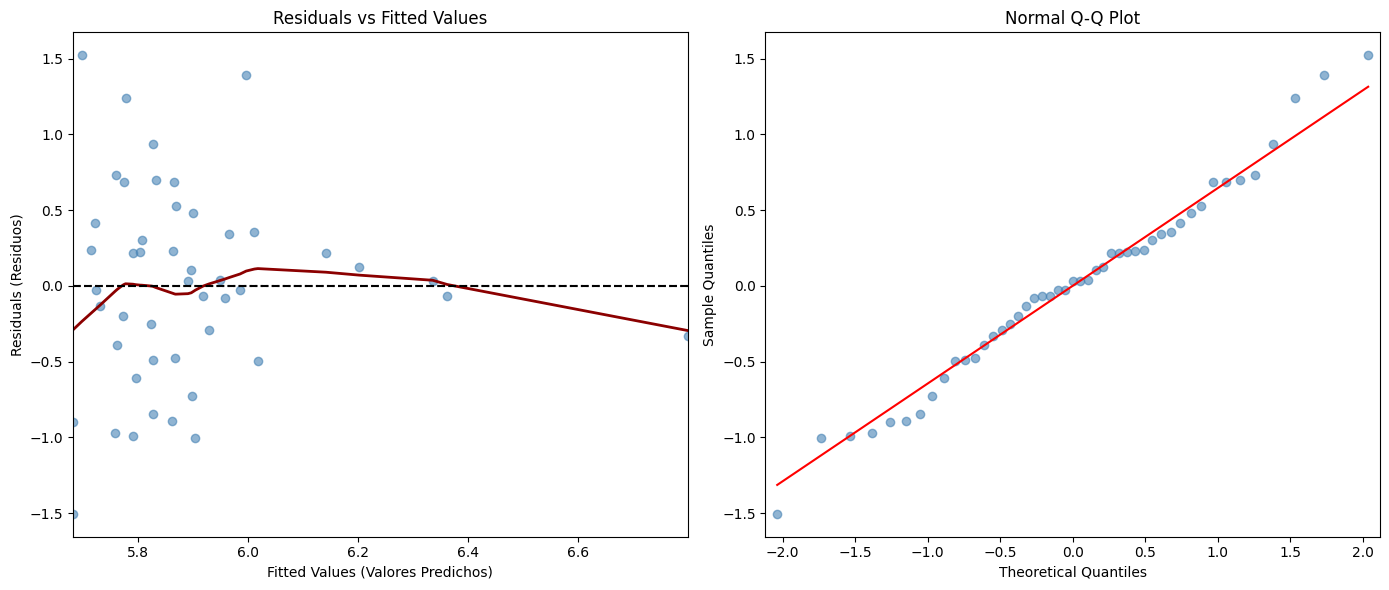

In [ ]:
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import seaborn as sns

print("=== PARTE 3.1: ELECCIÓN DEL OUTCOME CONTINUO ===")
print("Outcome elegido: 'grd_mean_los' (Promedio de días de estadía hospitalaria).")
print("Razón: Es un indicador continuo fundamental de la complejidad y costo de atención por comuna.")

# === PREPARACIÓN DE DATOS ===
# Usamos el df_model que ya excluyó a Santiago. Filtramos NaNs del nuevo outcome.
df_ols = df_model.dropna(subset=['grd_mean_los', 'pct_foreign', 'schooling_gap']).copy()

# ---------------------------------------------------------
# PARTE 3.2: REGRESIÓN LINEAL (OLS)
# ---------------------------------------------------------
print("\n=== PARTE 3.2: REGRESIÓN LINEAL (OLS) ===")
# Fórmula: grd_mean_los ~ pct_foreign + schooling_gap
formula_ols = "grd_mean_los ~ pct_foreign + schooling_gap"

# Ajustar el modelo OLS
ols_model = smf.ols(formula=formula_ols, data=df_ols).fit()
print(ols_model.summary())

# ---------------------------------------------------------
# PARTE 3.3: GRÁFICOS DE DIAGNÓSTICO
# ---------------------------------------------------------
print("\n=== PARTE 3.3: DIAGNÓSTICO DE SUPUESTOS OLS ===")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 1. Gráfico de Residuos vs Fitted Values (Evalúa homocedasticidad y linealidad)
sns.residplot(x=ols_model.fittedvalues, y=ols_model.resid, lowess=True,
              ax=axes[0], scatter_kws={'alpha': 0.6, 'color': 'steelblue'}, line_kws={'color': 'darkred', 'lw': 2})
axes[0].set_title('Residuals vs Fitted Values', fontsize=12)
axes[0].set_xlabel('Fitted Values (Valores Predichos)')
axes[0].set_ylabel('Residuals (Residuos)')
axes[0].axhline(0, color='black', linestyle='--')

# 2. QQ-Plot de los Residuos (Evalúa normalidad de los errores)
sm.qqplot(ols_model.resid, line='s', ax=axes[1], marker='o', alpha=0.6, markerfacecolor='steelblue', markeredgecolor='steelblue')
axes[1].set_title('Normal Q-Q Plot', fontsize=12)

plt.tight_layout()
plt.show()

### Part 4: Ecological Fallacy

1. La diferencia entre asociación ecológica e individual

Una asociación a nivel individual afirma que una característica específica de una persona cambia directamente la probabilidad de que esa misma persona experimente un resultado de salud. Por el contrario, una asociación ecológica ocurre cuando la unidad de análisis es un grupo, bloque geográfico o, en nuestro caso, una comuna. La correlación se establece entre los promedios o proporciones del grupo, no entre los atributos de los individuos que lo componen. Asumir que las reglas matemáticas que gobiernan a las poblaciones aplican mecánicamente a los individuos es el error lógico conocido como la falacia ecológica.


2. Riesgo de lectura errónea en nuestros resultados

En nuestro modelo inicial de Poisson (antes de corregir la sobredispersión), encontramos una asociación estadística positiva y significativa entre el porcentaje de población extranjera (pct_foreign) y la tasa de notificaciones ENO por comuna (eno_rate_per_10k). Un tomador de decisiones inexperto podría cometer la falacia ecológica al afirmar: "Si eres extranjero, tienes más probabilidades de enfermarte y ser notificado en el sistema ENO". Esta es una lectura causal individual falsa. Lo que el modelo ecológico realmente dice es que las comunas con mayor presencia migrante tienen mayores tasas de notificación general. Es perfectamente posible que en esas comunas sean los chilenos residentes quienes se están enfermando a tasas alarmantes debido a factores de hacinamiento o pobreza zonal, no la población migrante en sí misma. El dato ecológico no nos permite desagregar quién es el paciente notificado.


3. Utilidad del dato ecológico para la salud pública

A pesar de no poder hacer afirmaciones causales individuales, la asociación ecológica que hemos construido es tremendamente útil para la planificación sanitaria y la gestión del territorio. Por ejemplo, saber que las comunas con mayor hacinamiento o brecha educativa presentan altas tasas de hospitalización nos permite focalizar eficientemente los recursos del Estado. Si el Ministerio de Salud necesita decidir dónde instalar un nuevo SAPU (Servicio de Atención Primaria de Urgencia) o a qué municipio enviarle campañas de vacunación intensiva, los modelos ecológicos entregan el mapa de vulnerabilidad geográfica exacto para asignar esos presupuestos, independientemente de la identidad individual de quién usará la cama.


4. Amenazas adicionales a la inferencia

Más allá de la falacia ecológica, nuestro modelamiento transversal adolece de una amenaza metodológica importante que no ha sido abordada: la autocorrelación espacial. Nuestros modelos GLM asumen que las observaciones (las 51 comunas de la RM) son independientes entre sí. Sin embargo, en el mundo real, los problemas de salud son altamente contagiosos geográficamente. Un brote infeccioso en la comuna de Estación Central inevitablemente "derramará" notificaciones ENO hacia las comunas colindantes como Santiago o Quinta Normal. Esto viola el supuesto de independencia de los errores de nuestras regresiones. Para abordar esto en un trabajo futuro, la técnica adecuada sería abandonar el GLM estándar e implementar un Modelo de Rezago Espacial (Spatial Lag Model) o un Modelo de Error Espacial (Spatial Error Model). Esto permitiría controlar matemáticamente el "contagio" de la varianza entre polígonos vecinos, entregando coeficientes demográficos mucho más limpios e insesgados.


### Part 5: Spatial Visualization of Model Output

Importancia Técnica del Código

La relevancia radica en:
* Detección de Patrones Espaciales: Al mapear los residuos de Pearson, el código permite ver si los errores del modelo son aleatorios o si están agrupados geográficamente. Si ves "manchas" de colores similares, es la prueba empírica de la autocorrelación espacial que mencionaste en tu texto.
* Identificación de Anomalías (Outliers): El cálculo de nlargest y nsmallest identifica qué comunas "desafían" las reglas generales del modelo, permitiendo una investigación cualitativa posterior.
* Visualización de Riesgo Relativo (IRR): El Forest Plot es el estándar de oro en salud pública para comunicar el impacto. Transforma coeficientes matemáticos abstractos en "razones de tasa de incidencia" (IRR) fáciles de entender para tomadores de decisiones.

Interpretación de Resultados

1. El Mapa de Residuos:

Observando el Pearson Residuals Map:
* Subestimación Crítica: La comuna 13505 (Alhué) aparece en rojo intenso con un residuo de 9.37. Esto significa que Alhué tiene muchísimas más notificaciones ENO de lo que su educación o población extranjera predecirían.
* ¿Qué nos dice esto? Que en las zonas rurales extremas de la RM operan factores (quizás ambientales o de brotes específicos) que el modelo actual no captura.
* Sobreestimación: Las comunas en azul (como Melipilla 13504 o San José de Maipo 13403) tienen menos casos de los esperados, sugiriendo factores protectores territoriales.
2. Forest Plot

En el gráfico 5.3:
* Schooling Gap (El Ganador): El punto está claramente a la derecha del 1 (Efecto Nulo), con un IRR aproximado de 1.5. Interpretación: Por cada unidad que aumenta la brecha educativa, la tasa de notificaciones ENO aumenta en un 50%. Al no tocar la línea azul (1.0), confirmamos su significancia estadística absoluta.
* Pct_foreign (El Efecto Nulo): El "bigote" (intervalo de confianza) de esta variable cruza la línea azul del 1.0. Esto visualiza lo que vimos en la Parte 2, que el porcentaje de extranjeros no es un predictor confiable de la tasa de enfermedades cuando ajustamos correctamente la varianza.
* Alpha: Al ser mayor a 1 y estar lejos del efecto nulo, justifica visualmente por qué usamos la Binomial Negativa y no Poisson.

=== PARTE 5: PREPARANDO PREDICCIONES Y RESIDUOS ===
Top 3 Comunas que el modelo SUBESTIMÓ (mayores residuos positivos):
    codigo_comuna  pearson_resid
45          13505       9.376294
0            5101       2.252222
12          13112       1.209419

Top 3 Comunas que el modelo SOBREESTIMÓ (mayores residuos negativos):
    codigo_comuna  pearson_resid
44          13504      -1.259832
39          13403      -1.199519
36          13302      -1.038080


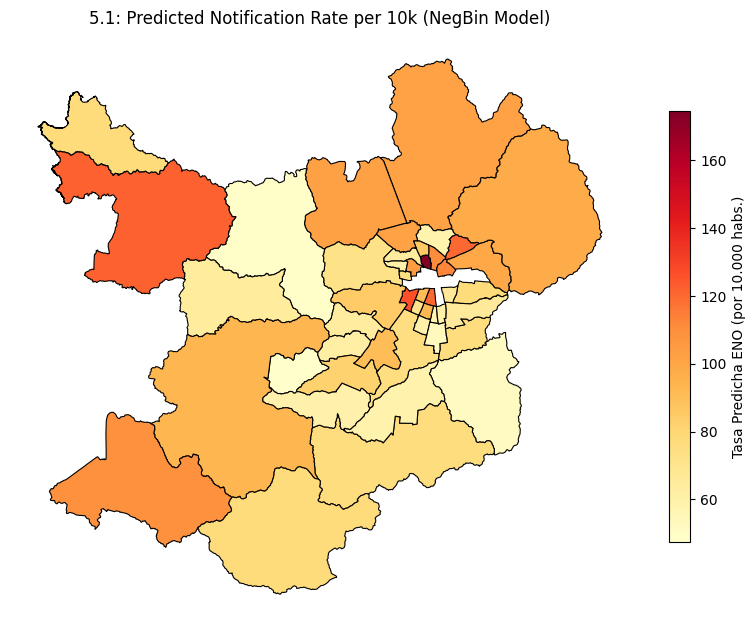

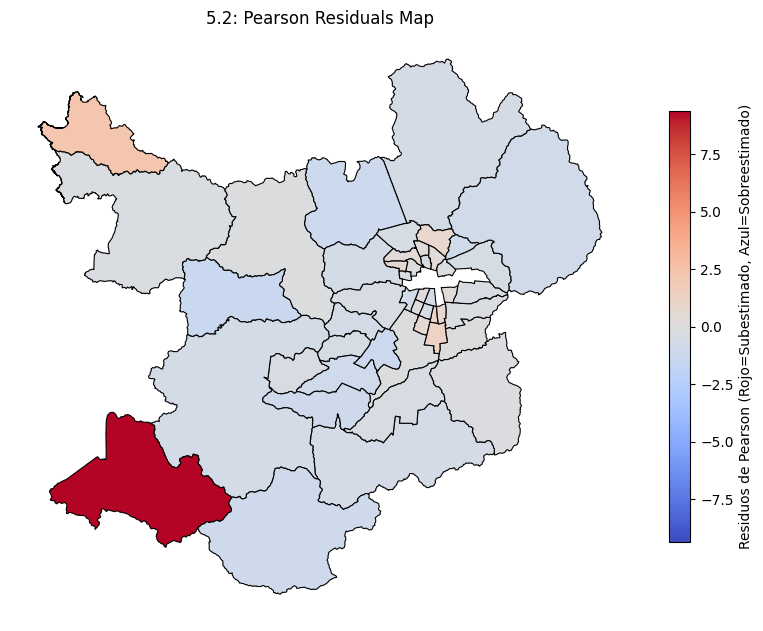


=== PARTE 5.3: COEFFICIENT PLOT (FOREST PLOT) ===


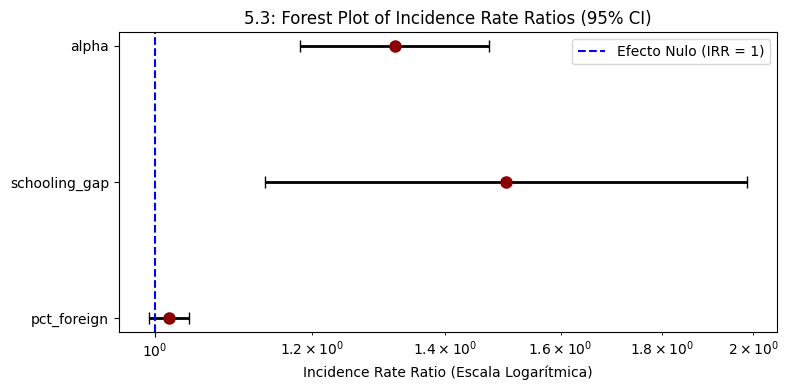

In [ ]:
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

print("=== PARTE 5: PREPARANDO PREDICCIONES Y RESIDUOS ===")
# 1. Calcular predicciones usando el modelo Binomial Negativo (nb_model) de ENO (Parte 2)
df_model['predicted_eno'] = nb_model.predict()
df_model['predicted_eno_rate_10k'] = (df_model['predicted_eno'] / df_model['pop_total']) * 10000

# 2. Extraer los residuos estandarizados de Pearson
df_model['pearson_resid'] = nb_model.resid_pearson

# Encontrar los extremos para el análisis escrito
print("Top 3 Comunas que el modelo SUBESTIMÓ (mayores residuos positivos):")
print(df_model.nlargest(3, 'pearson_resid')[['codigo_comuna', 'pearson_resid']])

print("\nTop 3 Comunas que el modelo SOBREESTIMÓ (mayores residuos negativos):")
print(df_model.nsmallest(3, 'pearson_resid')[['codigo_comuna', 'pearson_resid']])

# ---------------------------------------------------------
# CARGA DEL MAPA (5.1 y 5.2)
# ---------------------------------------------------------
try:
    # ¡LA CORRECCIÓN!: Agregamos el '/' para buscar en la raíz absoluta
    comunas_gdf = gpd.read_file("/comunas.shp")

    # Buscar dinámicamente la columna que contiene los códigos de comuna
    col_codigo = None
    for col in comunas_gdf.columns:
        if comunas_gdf[col].astype(str).str.contains('13132').any():
            col_codigo = col
            break

    if col_codigo:
        comunas_gdf[col_codigo] = pd.to_numeric(comunas_gdf[col_codigo])
        # Unir el mapa con los datos de nuestro modelo
        map_data = comunas_gdf.merge(df_model, left_on=col_codigo, right_on='codigo_comuna', how='inner')

        # === PARTE 5.1: MAPA DE TASAS PREDICHAS ===
        fig1, ax1 = plt.subplots(1, 1, figsize=(10, 8))
        map_data.plot(column='predicted_eno_rate_10k', cmap='YlOrRd', linewidth=0.8, ax=ax1,
                      edgecolor='black', legend=True,
                      legend_kwds={'label': "Tasa Predicha ENO (por 10.000 habs.)", 'shrink': 0.7})
        ax1.set_title("5.1: Predicted Notification Rate per 10k (NegBin Model)")
        ax1.axis('off')
        plt.show()

        # === PARTE 5.2: MAPA DE RESIDUOS ===
        fig2, ax2 = plt.subplots(1, 1, figsize=(10, 8))
        # Centrar en cero matemáticamente para que la paleta divergente funcione bien
        vmax = max(abs(map_data['pearson_resid'].min()), abs(map_data['pearson_resid'].max()))
        vmin = -vmax

        map_data.plot(column='pearson_resid', cmap='coolwarm', linewidth=0.8, ax=ax2,
                      edgecolor='black', legend=True, vmin=vmin, vmax=vmax,
                      legend_kwds={'label': "Residuos de Pearson (Rojo=Subestimado, Azul=Sobreestimado)", 'shrink': 0.7})
        ax2.set_title("5.2: Pearson Residuals Map")
        ax2.axis('off')
        plt.show()

    else:
        print("Error: No encontré la columna de códigos en el shapefile.")
except Exception as e:
    print(f"Error al cargar los mapas. Detalle: {e}")

# ---------------------------------------------------------
# PARTE 5.3: COEFFICIENT PLOT (FOREST PLOT)
# ---------------------------------------------------------
print("\n=== PARTE 5.3: COEFFICIENT PLOT (FOREST PLOT) ===")
# Extraer parámetros e intervalos de confianza, excluyendo el intercepto (que distorsiona el gráfico)
params = nb_model.params.drop('Intercept', errors='ignore')
conf_int = nb_model.conf_int().drop('Intercept', errors='ignore')

# Convertir a escala de Rate Ratios (IRR)
irrs = np.exp(params)
lower_ci = np.exp(conf_int[0])
upper_ci = np.exp(conf_int[1])

# Calcular el largo de los "bigotes" del error
errors = [irrs - lower_ci, upper_ci - irrs]

fig3, ax3 = plt.subplots(figsize=(8, 4))
ax3.errorbar(irrs, irrs.index, xerr=errors, fmt='o', color='darkred',
             ecolor='black', elinewidth=2, capsize=4, markersize=8)

# Marcar el efecto nulo (IRR = 1)
ax3.axvline(x=1, color='blue', linestyle='--', label='Efecto Nulo (IRR = 1)')
ax3.set_title("5.3: Forest Plot of Incidence Rate Ratios (95% CI)")
ax3.set_xlabel("Incidence Rate Ratio (Escala Logarítmica)")
ax3.set_xscale('log')
ax3.legend()

plt.tight_layout()
plt.show()

### Part 6: Integrated Synthesis

1. El Retrato Demográfico (De la Tarea 1 a la Comuna)

El análisis del Censo revela que la Región Metropolitana es un territorio profundamente segregado. El eje dominante de variación comunal es socioeconómico y territorial. Observamos comunas del sector oriente con pirámides envejecidas y alta escolaridad, contrastando con el sector sur y poniente (ej. La Pintana, Cerro Navia) que albergan poblaciones con mayores niveles de hacinamiento y brechas educativas. La migración reciente se ha insertado en esta matriz de manera desigual, concentrándose en zonas céntricas y pericentrales, aportando un bono demográfico joven pero tensionando la densidad intradomiciliaria.


2. El Mapa del Paisaje Sanitario (La Tarea 2 en Perspectiva)

El perfil hospitalario (GRD) responde directamente a esta matriz demográfica. Las comunas envejecidas demandan hospitalizaciones largas por enfermedades crónicas y oncológicas complejas. En contraste, el "Efecto del Migrante Sano" se evidenció con fuerza, el Capítulo XV (Embarazo, parto y puerperio) lideró las causas de egreso hospitalario en la población extranjera, caracterizándose por estadías cortas y severidad clínica mínima. Esto desmiente la narrativa de colapso hospitalario por morbilidad en población migrante, demostrando que su mayor interacción con el sistema de salud obedece a procesos reproductivos propios de su juventud.


3. El Valor de los Modelos Cruzados (El aporte de la Tarea 3)

La Matriz de Correlación sugería erróneamente que una mayor proporción de migrantes impulsaba mayores notificaciones ENO. Sin embargo, la regresión Binomial Negativa demostró su valor epidemiológico, al controlar matemáticamente por la sobredispersión y el tamaño poblacional, la proporción de extranjeros (pct_foreign) perdió toda significancia estadística (p = 0.172). La migración no predice per se un aumento en la carga de enfermedad.


El modelo cruzado reveló, en cambio, que la brecha educativa (schooling_gap) sí actúa como un fuerte predictor estructural de salud comunal. Finalmente, el análisis espacial de los residuos comprobó que la demografía no es destino. Comunas rurales como San Pedro sufren cargas de enfermedad altísimas invisibles para la estadística urbana tradicional, mientras que comunas periurbanas como María Pinto o Calera de Tango parecen tener buena salud solo porque sus enfermos se ven obligados a diagnosticarse y notificarse en el centro de la capital. La geografía y el acceso a la infraestructura determinan el dato tanto como la demografía.